In [9]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

In [79]:
df_main = pd.read_csv("/Users/romain/Desktop/Projets DS/ProjetStat/data/data_final/FINAL_GRAVITY_TRAINING_MATRIX.csv")
#print(gravity_data.head())
df_main.columns

df_main= df_main.drop(columns=['iso3.x','iso3.y'])


df_main.rename(columns={'cod_o': 'iso_o', 'cod_d': 'iso_d','year0':'year'}, inplace=True)
df_main.columns




Index(['orig', 'dest', 'iso_d', 'year', 'iso_o', 'flow', 'P_it', 'PSR_i',
       'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt',
       'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij', 'COL_ij',
       't_2000', 't_2000_sq'],
      dtype='object')

In [80]:
# 1. Nombre d'années différentes
nb_annees = df_main['year'].nunique()

# 2. Nombre total de lignes
nb_lignes = len(df_main)  # ou df_main.shape[0]

# 3. Nombre de codes ISO numériques différents (Origine)
nb_iso = df_main['iso_o'].nunique()

print(f"Années distinctes      : {nb_annees}")
print(f"Nombre total de lignes : {nb_lignes:,}")
print(f"Codes ISO uniques      : {nb_iso}")

# Bonus : Voir quelles sont les années disponibles
print("Liste des années :", df_main['year'].unique())

Années distinctes      : 6
Nombre total de lignes : 104,975
Codes ISO uniques      : 188
Liste des années : [2005 2010 2015 1995 2000 1990]


Faire des stats sur les données manquantes. 

In [49]:
df_main.describe()

,cod_d,year0,cod_o,flow,P_it,PSR_i,IMR_it,urban_it,LA_i,LL_i,...,IMR_jt,urban_jt,LA_j,LL_j,D_ij,LB_ij,OL_ij,COL_ij,t_2000,t_2000_sq
count,104975.000000,104975.000000,104975.000000,1.049750e+05,1.049750e+05,104975.000000,104975.000000,102957.000000,1.049750e+05,104975.000000,...,104975.000000,103410.000000,1.049750e+05,104975.000000,104975.000000,104975.000000,104975.000000,104975.000000,104975.000000,104975.000000
mean,423.789045,2002.694165,429.335594,4.374578e+03,4.596292e+04,12.148802,0.029950,58.976145,9.865850e+05,0.174041,...,0.027228,61.179377,1.004878e+06,0.168173,6740.322568,0.031465,0.177204,0.021719,2.694165,79.825673
std,251.076627,8.518676,252.350491,3.828313e+04,1.556215e+05,10.608185,0.032614,23.028839,2.458540e+06,0.379147,...,0.031061,22.064888,2.517817e+06,0.374022,4430.923263,0.174571,0.381843,0.145767,8.518676,75.906717
min,4.000000,1990.000000,4.000000,1.000000e+00,6.215200e+01,2.344076,0.001258,5.274941,2.500000e+01,0.000000,...,0.001258,5.274941,2.500000e+01,0.000000,59.617230,0.000000,0.000000,0.000000,-10.000000,0.000000
25%,208.000000,1995.000000,214.000000,5.000000e+00,3.501842e+03,5.202632,0.005914,39.982442,4.309400e+04,0.000000,...,0.005483,44.211003,4.522700e+04,0.000000,3051.854000,0.000000,0.000000,0.000000,-5.000000,25.000000
50%,410.000000,2005.000000,417.000000,4.500000e+01,9.404499e+03,10.914468,0.016218,62.216537,2.075950e+05,0.000000,...,0.014338,65.376703,1.985000e+05,0.000000,6105.744000,0.000000,0.000000,0.000000,5.000000,100.000000
75%,634.000000,2010.000000,638.000000,5.200000e+02,3.104224e+04,15.942997,0.044557,77.761092,6.785000e+05,0.000000,...,0.037812,78.555428,6.522250e+05,0.000000,9548.833000,0.000000,0.000000,0.000000,10.000000,100.000000
max,894.000000,2015.000000,894.000000,3.309139e+06,1.406848e+06,125.663414,0.225902,100.000000,1.707540e+07,1.000000,...,0.225902,100.000000,1.707540e+07,1.000000,19812.040000,1.000000,1.000000,1.000000,15.000000,225.000000


In [47]:
df_main.head(10)

,orig,dest,cod_d,year0,cod_o,flow,iso3.x,P_it,PSR_i,IMR_it,...,IMR_jt,urban_jt,LA_j,LL_j,D_ij,LB_ij,OL_ij,COL_ij,t_2000,t_2000_sq
0,ABW,ARE,784,2005,533,1,ABW,100.028,8.145069,0.016373,...,0.007756,82.212283,83657.0,0,12735.010,0,0,0,5,25
1,ABW,ARE,784,2010,533,1,ABW,101.665,6.691366,0.014963,...,0.006525,83.371430,83657.0,0,12735.010,0,0,0,10,100
2,ABW,ARE,784,2015,533,1,ABW,104.339,5.699100,0.013734,...,0.005530,84.328438,83657.0,0,12735.010,0,0,0,15,225
3,ABW,ARG,32,1995,533,1,ABW,80.324,10.075261,0.018687,...,0.020055,88.185368,2766889.0,0,5396.220,0,1,0,-5,25
4,ABW,ARG,32,2000,533,1,ABW,90.866,9.141363,0.018008,...,0.016981,89.176027,2766889.0,0,5396.220,0,1,0,0,0
5,ABW,ARG,32,2005,533,1,ABW,100.028,8.145069,0.016373,...,0.014377,90.123374,2766889.0,0,5396.220,0,1,0,5,25
6,ABW,ARG,32,2010,533,1,ABW,101.665,6.691366,0.014963,...,0.012174,90.993005,2766889.0,0,5396.220,0,1,0,10,100
7,ABW,ARG,32,2015,533,5,ABW,104.339,5.699100,0.013734,...,0.010308,91.492302,2766889.0,0,5396.220,0,1,0,15,225
8,ABW,ATG,28,1990,533,1,ABW,62.152,8.855401,0.019028,...,0.020965,35.490088,442.0,0,1024.995,0,0,0,-10,100
9,ABW,ATG,28,1995,533,2,ABW,80.324,10.075261,0.018687,...,0.015298,34.604587,442.0,0,1024.995,0,0,0,-5,25


In [13]:

#df_geo= pd.read_excel("data/geo_cepii.xls")


# On prépare une version light de la table geo

#geo_subset = df_geo[['iso3', 'landlocked']]

# ajouter landlocked_o

#df_main = df_main.merge(geo_subset, left_on='iso3_o', right_on='iso3', how='left')

# La colonne s'ajoute sous le nom 'landlocked', on la renomme tout de suite
#df_main = df_main.rename(columns={'landlocked': 'landlocked_o'})

# On supprime la colonne 'iso3' qui vient d'être ajoutée en doublon (celle de la table geo)
#df_main = df_main.drop(columns=['iso3'])

#ajouter landlocked_d
#df_main = df_main.merge(geo_subset, left_on='iso3_d', right_on='iso3', how='left')

# On renomme pour la destination
#df_main = df_main.rename(columns={'landlocked': 'landlocked_d'})


#df_main = df_main.drop(columns=['iso3'])

# Vérification
#print(df_main[['iso3_o', 'landlocked_o', 'iso3_d', 'landlocked_d']].head())



In [35]:
df_main.head(50)
df_main.columns

Index(['orig', 'dest', 'cod_d', 'year0', 'cod_o', 'flow', 'iso3.x', 'P_it',
       'PSR_i', 'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'iso3.y', 'P_jt',
       'PSR_j', 'IMR_jt', 'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij',
       'COL_ij', 't_2000', 't_2000_sq'],
      dtype='object')

In [ ]:
# EXPORTER EN CSV 


#output_path = '/Users/romain/Desktop/Projets DS/ProjetStat/data/data_prediction.csv'

# exportation propre
#df_main.to_csv(
#    output_path, 
#    index=False,   # CRUCIAL : Ne pas enregistrer la colonne d'index (0, 1, 2...)
 #   na_rep='NA',   # CRUCIAL POUR R : Remplacer les vides par "NA"
 #   sep=',',       # Standard international (virgule)
 #   encoding='utf-8'
#)

In [ ]:
# à faire: prendre les log 
# revoir les noms (ne s'appelle plus contig etc...)
# se fier aux noms de l'article 
# compter nombre de lignes pour vérifier. 

In [ ]:
import statsmodels.formula.api as smf

import numpy as np # Indispensable pour que la formule comprenne "np.log"

formula = """
np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq
"""


# cov_type='HC1' heteroskedasticity
results = smf.ols(formula, data=df_main.dropna()).fit(cov_type='HC1')


print(results.summary())
print(f"R-squared précis : {results.rsquared:.6f}")
R2_previous = results.rsquared
print(f"Adj. R-squared   : {results.rsquared_adj:.6f}")
R2_adj_previous = results.rsquared_adj

                            OLS Regression Results                            
Dep. Variable:           np.log(flow)   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     6658.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:39:54   Log-Likelihood:            -2.1927e+05
No. Observations:              101476   AIC:                         4.386e+05
Df Residuals:                  101457   BIC:                         4.388e+05
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.0538      0.159  

test regression avec dist*contig

In [18]:
import statsmodels.formula.api as smf


formula_2 = """
np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + np.log(D_ij)*LB_ij
"""


# cov_type='HC1' heteroskedasticity
results2 = smf.ols(formula_2, data=df_main.dropna()).fit(cov_type='HC1')


print(results2.summary())

print(f"R-squared précis : {results2.rsquared:.6f}")
print(f"Adj. R-squared   : {results2.rsquared_adj:.6f}")

R2_new = results2.rsquared
R2_adj_new = results2.rsquared_adj
print(f"Changement R-squared : {R2_new - R2_previous:.6f}")
print(f"Changement Adj. R-squared : {R2_adj_new - R2_adj_previous:.6f}")

                            OLS Regression Results                            
Dep. Variable:           np.log(flow)   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     6403.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:41:01   Log-Likelihood:            -2.1925e+05
No. Observations:              101476   AIC:                         4.385e+05
Df Residuals:                  101456   BIC:                         4.387e+05
Df Model:                          19                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -3.9741      0

In [50]:
df_cepii = pd.read_csv("/Users/romain/Desktop/Projets DS/ProjetStat/data/data_final/reg_gravity_CEPII.csv")
df_cepii.head




/var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/ipykernel_86277/4146781709.py:1: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cepii = pd.read_csv("/Users/romain/Desktop/Projets DS/ProjetStat/data/data_final/reg_gravity_CEPII.csv")


<bound method NDFrame.head of         iso_o  iso_d origIso destIso  year  migrantCount country_id_o  \
0         533      4     ABW     AFG  1990             0          ABW   
1         533      4     ABW     AFG  1995             0          ABW   
2         533      4     ABW     AFG  2000             0          ABW   
3         533      4     ABW     AFG  2005             0          ABW   
4         533      4     ABW     AFG  2010             0          ABW   
...       ...    ...     ...     ...   ...           ...          ...   
198995    716    894     ZWE     ZMB  1990          9676          ZWE   
198996    716    894     ZWE     ZMB  1995          4514          ZWE   
198997    716    894     ZWE     ZMB  2000         11438          ZWE   
198998    716    894     ZWE     ZMB  2005          9939          ZWE   
198999    716    894     ZWE     ZMB  2010          9495          ZWE   

       country_id_d iso3_o iso3_d  ...  tradeflow_comtrade_o  \
0               AFG    ABW   

In [51]:
df_main.columns

Index(['orig', 'dest', 'cod_d', 'year0', 'cod_o', 'flow', 'P_it', 'PSR_i',
       'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt',
       'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij', 'COL_ij',
       't_2000', 't_2000_sq'],
      dtype='object')

In [ ]:
df_cepii.columns

df_cepii_subset = df_cepii[['iso_o']]


Index(['orig', 'dest', 'iso_d', 'year', 'iso_o', 'flow', 'P_it', 'PSR_i',
       'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt',
       'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij', 'COL_ij',
       't_2000', 't_2000_sq'],
      dtype='object')

In [53]:
import pandas as pd
import numpy as np


# On prend iso3 + year comme clés
cols_eco = ['iso_o', 'iso_d', 'year', 'gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d']
df_eco = df_cepii[cols_eco].copy()



# fusionner valeurs courantes, t 
df_final = df_main.merge(df_eco, on=['iso_o', 'iso_d', 'year'], how='left')



# fusionner valeurs retardées, t-5

# On crée une colonne 'year_target' = année actuelle + 5 ans.
# L'année 2000 du fichier éco viendra s'accrocher à l'année 2005 du fichier principal.
df_eco_lag = df_eco.copy()
df_eco_lag['year_target'] = df_eco_lag['year'] + 5 

# On renomme les colonnes pour éviter les doublons (suffixe _lag)
cols_lag = {c: f'{c}_lag' for c in ['gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d']}
df_eco_lag = df_eco_lag.rename(columns=cols_lag)

# Fusion sur les clés + la clé temporelle décalée
df_final = df_final.merge(
    df_eco_lag[['iso_o', 'iso_d', 'year_target'] + list(cols_lag.values())],
    left_on=['iso_o', 'iso_d', 'year'],
    right_on=['iso_o', 'iso_d', 'year_target'],
    how='left'
)

# calcul des log (gérer les NaN)
vars_to_log = ['gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d', 
               'gdp_o_lag', 'gdp_d_lag', 'gdpcap_o_lag', 'gdpcap_d_lag']

for col in vars_to_log:
    # On remplace les valeurs <= 0 par NaN pour éviter l'erreur log(0)
    # Statsmodels supprimera automatiquement ces lignes lors de la régression
    df_final[col] = df_final[col].apply(lambda x: x if x > 0 else np.nan)
    df_final[f'log_{col}'] = np.log(df_final[col])


df_final = df_final.drop(columns=['year_target'])

print("Fusion terminée.")
print(df_final[['year', 'log_gdpcap_o', 'log_gdpcap_o_lag']].head())

Fusion terminée.
   year  log_gdpcap_o  log_gdpcap_o_lag
0  2005      3.148582          3.026261
1  2010      3.190024          3.148582
2  2015           NaN          3.190024
3  1995      2.799778               NaN
4  2000      3.026261          2.799778


In [54]:
df_final.head(50)

,orig,dest,iso_d,year,iso_o,flow,P_it,PSR_i,IMR_it,urban_it,...,gdpcap_o_lag,gdpcap_d_lag,log_gdp_o,log_gdp_d,log_gdpcap_o,log_gdpcap_d,log_gdp_o_lag,log_gdp_d_lag,log_gdpcap_o_lag,log_gdpcap_d_lag
0,ABW,ARE,784,2005,533,1,100.028,8.145069,0.016373,64.958023,...,20.620,34.476,14.661810,19.011889,3.148582,3.773542,14.443294,18.463140,3.026261,3.540263
1,ABW,ARE,784,2010,533,1,101.665,6.691366,0.014963,64.161297,...,23.303,43.534,14.718799,19.471675,3.190024,3.523002,14.661810,19.011889,3.148582,3.773542
2,ABW,ARE,784,2015,533,1,104.339,5.699100,0.013734,63.228837,...,24.289,33.886,NaN,NaN,NaN,NaN,14.718799,19.471675,3.190024,3.523002
3,ABW,ARG,32,1995,533,1,80.324,10.075261,0.018687,65.376703,...,NaN,4.333,14.093650,19.560336,2.799778,2.194220,NaN,18.766766,NaN,1.466260
4,ABW,ARG,32,2000,533,1,90.866,9.141363,0.018008,65.354550,...,16.441,8.973,14.443294,19.656945,3.026261,2.233128,14.093650,19.560336,2.799778,2.194220
5,ABW,ARG,32,2005,533,1,100.028,8.145069,0.016373,64.958023,...,20.620,9.329,14.661810,19.222268,3.148582,1.752325,14.443294,19.656945,3.026261,2.233128
6,ABW,ARG,32,2010,533,1,101.665,6.691366,0.014963,64.161297,...,23.303,5.768,14.718799,19.952598,3.190024,2.438863,14.661810,19.222268,3.148582,1.752325
7,ABW,ARG,32,2015,533,5,104.339,5.699100,0.013734,63.228837,...,24.289,11.460,NaN,NaN,NaN,NaN,14.718799,19.952598,3.190024,2.438863
8,ABW,ATG,28,1990,533,1,62.152,8.855401,0.019028,65.432816,...,NaN,NaN,NaN,12.877921,NaN,1.844510,NaN,NaN,NaN,NaN
9,ABW,ATG,28,1995,533,2,80.324,10.075261,0.018687,65.376703,...,NaN,6.325,14.093650,13.110666,2.799778,1.978239,NaN,12.877921,NaN,1.844510


In [59]:
# TEST GDP VS GDP PER CAPITA (intuition gdcpcap plus pertinent)


formula = """
np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + log_gdp_o + log_gdp_d
"""

# cov_type='HC1' pour heteroskedascticity
results1 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')


print(results1.summary())

formula_2 = """
np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + log_gdpcap_o + log_gdpcap_d
"""
results2 = smf.ols(formula_2, data=df_final.dropna()).fit(cov_type='HC1')
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:           np.log(flow)   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     4092.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:57:55   Log-Likelihood:            -1.2212e+05
No. Observations:               57959   AIC:                         2.443e+05
Df Residuals:                   57938   BIC:                         2.445e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.4261      0.199  

In [61]:
# TEST GDP RETARDÉ vs GDP COURANT 

formula = """ np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + + log_gdpcap_o_lag + log_gdpcap_d_lag
"""


# cov_type='HC1' pour heteroskedascticity
results1 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')


print(results1.summary())

formula= """np.log(flow) ~  np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + + log_gdpcap_o + log_gdpcap_d"""
results2 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:           np.log(flow)   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     4099.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:59:21   Log-Likelihood:            -1.2206e+05
No. Observations:               57959   AIC:                         2.442e+05
Df Residuals:                   57938   BIC:                         2.443e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.2160      0.233  

In [62]:
df_final.columns

Index(['orig', 'dest', 'iso_d', 'year', 'iso_o', 'flow', 'P_it', 'PSR_i',
       'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt',
       'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij', 'COL_ij',
       't_2000', 't_2000_sq', 'gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d',
       'gdp_o_lag', 'gdp_d_lag', 'gdpcap_o_lag', 'gdpcap_d_lag', 'log_gdp_o',
       'log_gdp_d', 'log_gdpcap_o', 'log_gdpcap_d', 'log_gdp_o_lag',
       'log_gdp_d_lag', 'log_gdpcap_o_lag', 'log_gdpcap_d_lag'],
      dtype='object')

In [65]:
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Liste des colonnes BRUTES nécessaires pour le nettoyage
cols_needed = [
    'flow', 'year',
    'P_it', 'P_jt', 'D_ij', 
    'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 
    'urban_it', 'urban_jt', 'LA_i', 'LA_j', 
    'LL_i', 'LL_j', 
    'LB_ij', 'OL_ij', 'COL_ij', 
    't_2000', 't_2000_sq'
]

# 2. Nettoyage : On ne garde que les lignes complètes

df_clean = df_main.dropna(subset=cols_needed).copy()

# 3. Split Train/Test (Test = 2015)
train_df = df_clean[df_clean['year'] < 2015]
test_df  = df_clean[df_clean['year'] == 2015]

print(f"Train : {len(train_df)} | Test : {len(test_df)}")

# 4. Formule avec Logarithmes intégrés
# Correspondance : Origin=_i/_it, Dest=_j/_jt, Dyad=_ij
formula = """
np.log(flow) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq
"""

model = smf.ols(formula, data=train_df).fit()

# 5. Prédiction et Évaluation
pred_log = model.predict(test_df)

# Retour à l'échelle réelle 
y_pred_real = np.exp(pred_log)
y_true_real = test_df['flow']

# Métriques
mse = mean_squared_error(y_true_real, y_pred_real)
mape = mean_absolute_percentage_error(y_true_real, y_pred_real)

print(f"\n--- PERFORMANCE OLS (Baseline 2010) ---")
print(f"MSE  : {mse:,.0f}")
print(f"MAPE : {mape:.2%}")


Train : 84287 | Test : 17189

--- PERFORMANCE OLS (Baseline 2010) ---
MSE  : 2,841,521,770
MAPE : 807.32%


MSE ? MAPE ? comparaison avec ajout gdpcap et sans. 

Random forest: on attend une bosse migratoire, une cloche (pays pauvre: quand on commence à avoir les moyens on fuit, quand le pays devient asssez riche on reste)
L'effet de la distance est très mal jaugé par l'OLS: la distance joue t elle pareil en fonction de contig = 1 ou 0? on abesoin de dist*contig, que RF gère tout seul.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import PartialDependenceDisplay

# --- ADAPTATION AUX NOUVELLES COLONNES ---
# On crée une copie de travail pour ne pas toucher à l'original
df_ml = df_final.copy()

# 1. Renommage des variables brutes (Dummies & Temps)
df_ml = df_ml.rename(columns={
    'LL_i': 'landlocked_o', 
    'LL_j': 'landlocked_d',
    'LB_ij': 'contig', 
    'OL_ij': 'comlang_off', 
    'COL_ij': 'col_dep_ever',
    't_2000': 't_centered', 
    't_2000_sq': 't_centered_sq'
})

# 2. Création des variables Logarithmiques (Target + Features continues)
# Target (avec +1 pour gérer les 0)
df_ml['log_migrantCount'] = np.log(df_ml['flow'])

# Features
df_ml['log_pop_o']   = np.log(df_ml['P_it'])
df_ml['log_pop_d']   = np.log(df_ml['P_jt'])
df_ml['log_distcap'] = np.log(df_ml['D_ij'])
df_ml['log_PSR_o']   = np.log(df_ml['PSR_i'])
df_ml['log_PSR_d']   = np.log(df_ml['PSR_j'])
df_ml['log_IMR_o']   = np.log(df_ml['IMR_it'])
df_ml['log_IMR_d']   = np.log(df_ml['IMR_jt'])
df_ml['log_urban_o'] = np.log(df_ml['urban_it'])
df_ml['log_urban_d'] = np.log(df_ml['urban_jt'])
df_ml['log_LA_o']    = np.log(df_ml['LA_i'])
df_ml['log_LA_d']    = np.log(df_ml['LA_j'])

# (Note: tes colonnes log_gdpcap_o_lag existent déjà dans df_final, pas besoin de recréer)

# --- FIN ADAPTATION ---


#PREP DES DONNEES ET SPLIT TEMPOREL


# On reprend tes variables du "Modèle Lagged" (le plus performant économétriquement)
features = [
    'log_pop_o', 'log_pop_d', 'log_distcap', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d',
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d',
    'landlocked_o', 'landlocked_d', 
    'contig', 'comlang_off', 'col_dep_ever', 
    't_centered', 't_centered_sq', 
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]
target = 'log_migrantCount'

# Nettoyage strict (le RF ne gère pas les NaN)
df_ml = df_ml.dropna(subset=features + [target]).copy()

# Split Temporel 
# Train : 1990-2005 ; Test : 2010 (Année de prédiction) (il manque l'année 2015)
train_df = df_ml[df_ml['year'] < 2015]
test_df  = df_ml[df_ml['year'] == 2015].copy() 

X_train, y_train = train_df[features], train_df[target]
X_test, y_test   = test_df[features], test_df[target]




# FEATURE IMPORTANCE RF 


# Choix des arguments :
# - n_estimators=100 : Suffisant pour stabiliser la variance sans exploser le temps de calcul (nbre de jurés)
# - max_depth=20 : Plus profond que projet elections car les flux migratoires 
#   ont une variance plus complexe. Il faut capter des interactions fines.

rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Calcul des R^2
r2_train = r2_score(y_train, rf.predict(X_train))
r2_test  = r2_score(y_test, rf.predict(X_test))

print(f"R^2 Random Forest (Entraînement 1990-2010) : {r2_train:.4f}")
print(f"R^2 Random Forest (Prédiction 2015)       : {r2_test:.4f}")

# Hiérarchie des variables (feature importance)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables ")
print(importances.head(10))




R^2 Random Forest (Entraînement 1990-2010) : 0.9670
R^2 Random Forest (Prédiction 2015)       : 0.7563

Importance des variables 
log_distcap         0.172992
log_pop_o           0.165843
log_pop_d           0.147635
log_gdpcap_d_lag    0.102550
log_gdpcap_o_lag    0.061654
contig              0.041767
log_LA_d            0.036877
log_PSR_d           0.036041
log_LA_o            0.035209
log_IMR_d           0.034333
dtype: float64


R^2 random forest out of sample? 

In [70]:
# Erreurs MSE et MAPE

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Prédiction sur le Test (en Log)
y_pred_log = rf.predict(X_test)

#  Retour à l'échelle réelle (Exponentielle)
# On veut comparer des humains, pas des logs d'humains
y_pred_real = np.exp(y_pred_log)
y_true_real = np.exp(y_test)

# calcul des erreurs 
mse_rf = mean_squared_error(y_true_real, y_pred_real) #somme des ecarts au carré
mape_rf = mean_absolute_percentage_error(y_true_real, y_pred_real) # somme des écarts relatifs

print(f"\n PERFORMANCE PRÉDICTIVE (Test 2015) ")
print(f"MSE (Random Forest)  : {mse_rf:,.0f}")
print(f"MAPE (Random Forest) : {mape_rf:.2%}")


 PERFORMANCE PRÉDICTIVE (Test 2015) 
MSE (Random Forest)  : 509,727,340
MAPE (Random Forest) : 613.36%


Min/Max de la variable :
min   -2.733368
max    4.376939
Name: log_gdpcap_o_lag, dtype: float64


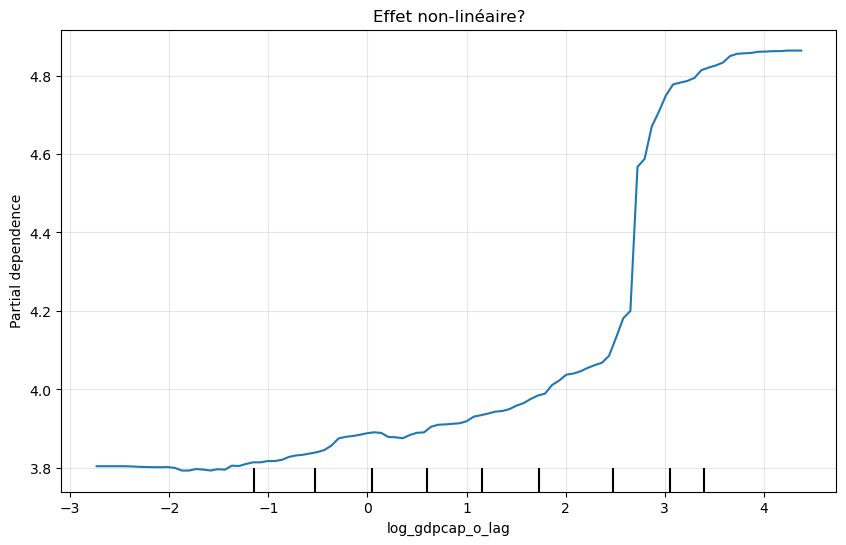

In [71]:
# PARTIAL DEPENDENCE PLOT (pour gdpcap)


import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Vérif de l'étendue réelle des données
print("Min/Max de la variable :")
print(X_train['log_gdpcap_o_lag'].describe()[['min', 'max']])

fig, ax = plt.subplots(figsize=(10, 6))


PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    ['log_gdpcap_o_lag'], 
    kind="average", 
    percentiles=(0, 1),  
    ax=ax
)

plt.title("Effet non-linéaire?")
plt.grid(True, alpha=0.3)
plt.show()

MOYENNE SUR TOUS LES PAYS ? faire nuage de points
diviser les données en deux groupes 

Log = -3 : 50$ par habitant. (Extrême pauvreté ou erreur de donnée).
Log = 2.5 : 12,100$ par habitant. (point de bascule).
Log = 3.0 : 20 000$ par habitant. (Entrée dans le club des pays occidentaux, c'est le seuil attendu)
Log = 4.4 : 80 000$ par habitant. (max dans le monde, qatar suisse etc)



nouvelles PDP en divisant deux groupes: >12k$ GDP/capita

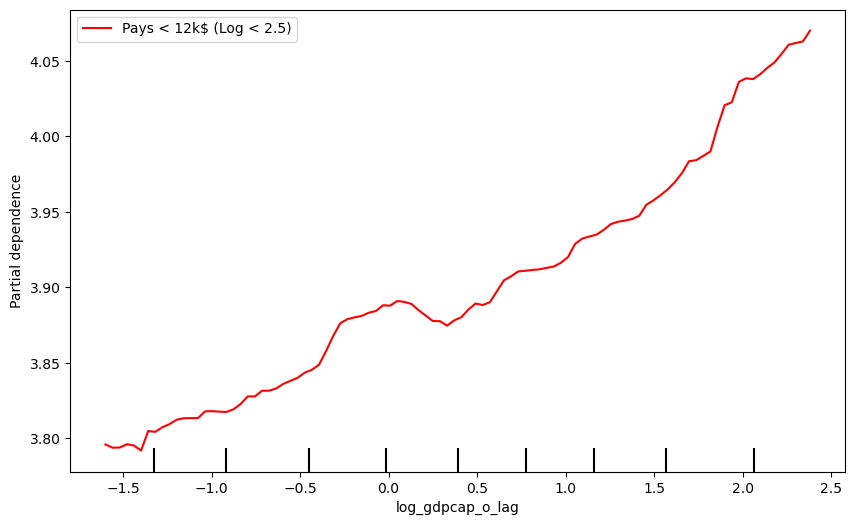

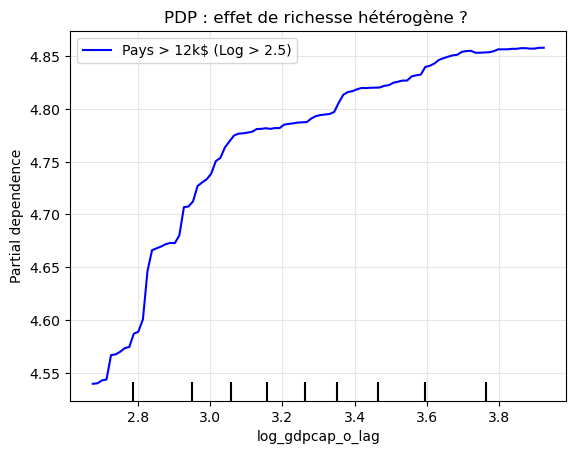

In [72]:


# Seuils log ~ 2.5 qui correspond à 12k$ GDP/capita
mask_pauvres = X_train['log_gdpcap_o_lag'] < 2.6
mask_riches  = X_train['log_gdpcap_o_lag'] >= 2.6

fig, ax = plt.subplots(figsize=(10, 6))

#  PDP Pays < Seuil (rouge)
PartialDependenceDisplay.from_estimator(
    rf, 
    X_train[mask_pauvres], 
    ['log_gdpcap_o_lag'], 
    kind="average", 
    line_kw={"color": "red", "label": "Pays < 12k$ (Log < 2.5)"},
    ax=ax
)

#  PDP Pays > Seuil (Bleu) 
PartialDependenceDisplay.from_estimator(
    rf, 
    X_train[mask_riches], 
    ['log_gdpcap_o_lag'], 
    kind="average", 
    line_kw={"color": "blue", "label": "Pays > 12k$ (Log > 2.5)"},
    
)

plt.title("PDP : effet de richesse hétérogène ? ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

NOTES DERNIERE REUNION: 

voir quels sont les pays concernés potentiels outlayers 
recommencer avec les données, ou les inférer si on a le temps. Mettre dans le rapport dans tous les cas (biais de sélection) 
décile supérieur des pays riches à compareren pourcentage au décile le plus bas (résultat surprenant à priori, mais finalement c'est bien ce qu'on observe)

essayer XGBoost avec scikit learn en boite noire 
comparer les MAPE comme avec random forest 
commencer à imaginer 

diviser les données en deux tas pour améliorer le MAPE: contiguité par exemple. ou autre variable non linéaire à seuil, indicatrice*variable.

prédire sur 2020 avec données disponibles. Out of sample prédiction vs in sample prediction


regression sur indactrice outflow: 
kappa les plus grands: Mex & US


ONYXIA SERVEUR DE CALCUL 
REGRESSION SUR INDICATRICE: estimation ad hoc, le but est de mieux initialiser les algorithmes MCMC (les priors). 

1er partie: regression lineaire ; 2e partie: RF ; 3e partie algos MCMC et resultats de Raftery et Welch 
stat desc à revoir: corrélation entre t et t-1 de log(\delta_it) avec delta_it taux de départ du pays i à la date t. Modèle AR(1) de Welch et Raftery (cours série temp) satisf°  

Equation log = mu(1-phi) + phi*log + epsilon. 

commencer à rédiger rapport notamment stat desc pour commencer à le faire valider par le prof. 

/opt/anaconda3/envs/datasci/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 13 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


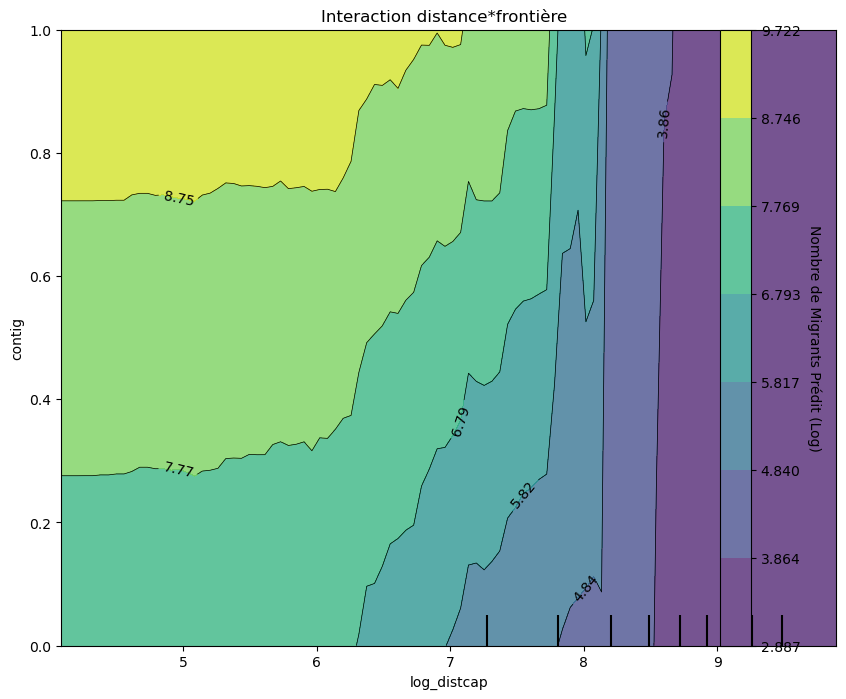

In [73]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# PDP 2D

features_inter = [('log_distcap', 'contig')] 
# ------------------

fig, ax = plt.subplots(figsize=(10, 8))

graph= PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    percentiles=(0, 1),   # Gamme complète
    n_cols=1,             
    ax=ax
)
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Nombre de Migrants Prédit (Log)', rotation=270, labelpad=15)
plt.title("Interaction distance*frontière  ")

plt.show()

montrer d'abord le graphe suivant pour la compréhension, qui lui est linéaire dans la progression en couleur vis à vis de l'axe X.


/opt/anaconda3/envs/datasci/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 11 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


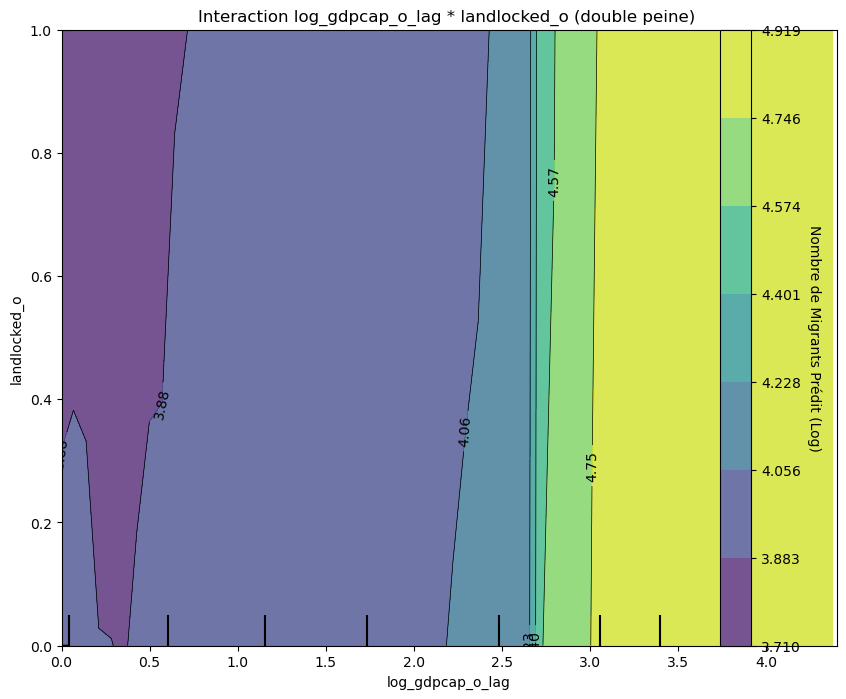

In [74]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# PDP 2D

features_inter = [('log_gdpcap_o_lag', 'landlocked_o')] 
# ------------------

fig, ax = plt.subplots(figsize=(10, 8))

graph= PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    percentiles=(0, 1),   # Gamme complète
    n_cols=1,             
    ax=ax
)
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Nombre de Migrants Prédit (Log)', rotation=270, labelpad=15)
plt.title("Interaction log_gdpcap_o_lag * landlocked_o (double peine) ")
plt.xlim(0,4.4)
plt.show()

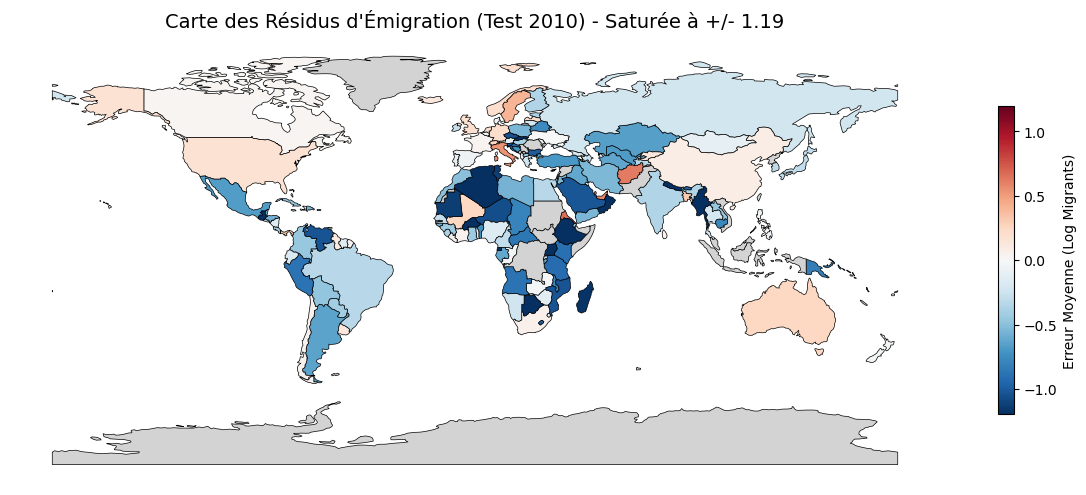

In [78]:
# Carte des Résidus 


# 1) Calcul des résidus
test_df['residuals'] = test_df[target] - rf.predict(X_test)
resid_by_country = test_df.groupby('orig')['residuals'].mean().reset_index()

# 2) Chargement du fond de carte (url directe natural earth)

url_world = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_world)

# 3) Harmonisation des codes ISO (Natural Earth utilise souvent 'ADM0_A3' ou 'ISO_A3')
# On s'assure d'avoir une colonne 'iso_a3' minuscule pour votre fusion
col_iso = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
world['iso_a3'] = world[col_iso]

# 4) Fusion
world_map = world.merge(resid_by_country, left_on='iso_a3', right_on='orig', how='left')

# 5) Vizu
v_max = world_map['residuals'].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(15, 8))
world_map.plot(
    column='residuals', 
    cmap='RdBu_r', 
    linewidth=0.5,
    edgecolor='black',
    ax=ax, 
    legend=True,
    vmin=-v_max, 
    vmax=v_max,
    missing_kwds={'color': 'lightgrey', 'label': 'Pas de données'},
    legend_kwds={'label': "Erreur Moyenne (Log Migrants)", 'shrink': 0.5}
)
ax.set_title(f"Carte des Résidus d'Émigration (Test 2010) - Saturée à +/- {v_max:.2f}", fontsize=14)
ax.axis('off')
plt.show()

Commentaires: 

ATTENTION avec gdpcap à t-5 on se trompe sur les Etats unis (sous estime). (?)


ZONES BLEUES (le modèle sur-estime les flux "réels")



- Niger Tchad Burkina Faso RépCentrafricaine: TRAPPE A PAUVRETé que le modèle a réussi à capter (cf courbe à seuil pour gdpcap_o), mais il en sous estime encore la puissance (il prédit un plus faible nombre de migrants, alors qu'en réalité ce nombre est vraiment proche du néant)

- Arabie Saoudite : le modèle voit un pays riche et connecté à l'international, il prédit une migration comparable aux pays occidentaux. En réalité, le pays est stabilisé par sa "rente pétrolière" qui achète et sédentarise les nationaux. 

- Chili : isolement géographique par les Andes ? stabilité culturelle, nationaux attachés peut être ? 

- Myanmar: dictature qui ferme le pays en 2010. 

- madagascar: combinaison de la trappe à pauvreté avec l'isolement insulaire, les billets d'avions sont infiniment chers pour les locaux.

- Algérie : le modèle capte la proxmité coloniale, mais en réalité l'obtention d'un visa Schenghen refroidit le potentiel de proximité coloniale. Le désir de migrer est là, la possiblité  légale l'est moins.

- Kazakhstan: le modèle a appris sur le départ des soviétiques après la chute de l'URSS en 90-2000, et a anticipté des trop gros flux en 2010 alors que l'économie s'était stabilisée. 



ZONES ROUGES (le modèle sous-estime les flux "réels")



- Libye: problème ici ? khadafi règnait jusqu'en 2011 et fermait le pays. 

- Israel : diaspora, israeliens ont souvent double nationalité, circulent facilement, hyper-mobilité que le modèle n'a pas capté.

- Rép du Congo Brazzaville: plus stable que le Congo Kinshasa, assez pauvre mais avec liens coloniaux français plus forts que le modèle pensait (variable gdpcap * dummy liens coloniaux ? )
Le modèle prédit bien pour Congo belge.

- Afrique du Sud: pays du BRICS très émergent, le modèle prévoit une stabilité et sédentarité. Or la criminalité assez fortement tjr présente pousse les classes moyennes/supérieures à fuir 




In [ ]:
import pandas as pd
from cmdstanpy import CmdStanModel

#liste de variables
features = [
    'log_pop_o', 'log_pop_d', 'log_distcap', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d',
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d',
    'landlocked_o', 'landlocked_d', 
    'contig', 'comlang_off', 'col_dep_ever', 
    't_centered', 't_centered_sq', 
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]

# 1. Préparation des données pour Stan
# Stan ne lit pas les DataFrame, il veut un dictionnaire avec des matrices numpy
stan_data = {
    'N': len(train_df),
    'K': len(features),
    'X': train_df[features].values,            # On passe tout le bloc X d'un coup
    'y': train_df['log_migrantCount'].values   # La cible
}

# 2. Compilation et Sampling

model = CmdStanModel(stan_file='MCMC.stan')

# On lance 4 chaînes en parallèle

# fit = model.sample(data=stan_data, chains=4, iter_sampling=1000)

# 3. Résultats
print(fit.summary())

19:15:33 - cmdstanpy - INFO - compiling stan file /var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/tmpfw9juw5j/tmp_gbjkltg.stan to exe file /Users/romain/Desktop/Projets DS/ProjetStat/MCMC
19:15:45 - cmdstanpy - INFO - compiled model executable: /Users/romain/Desktop/Projets DS/ProjetStat/MCMC


NameError: name 'fit' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Extraction des 4000 simulations (Posterior)
alpha_samples = fit.stan_variable('alpha')  # shape: (4000,)
beta_samples  = fit.stan_variable('beta')   # shape: (4000, 20)

# 2. Données de Test
X_test = test_df[features].values
y_true_real = np.exp(test_df['log_migrantCount']) # On veut comparer en "vrais" migrants


y_log_pred_samples = alpha_samples + np.dot(X_test, beta_samples.T)

# 4. Aggrégation : On prend la moyenne des prédictions (en log) puis on exponentie
y_pred_mean = np.exp(y_log_pred_samples.mean(axis=1))

# 5. Calcul des erreurs
mse_bayes = mean_squared_error(y_true_real, y_pred_mean)
mape_bayes = mean_absolute_percentage_error(y_true_real, y_pred_mean)

print(f"RÉSULTATS STAN (Test sur 2010 ) ")
print(f"MSE  : {mse_bayes:,.0f}")
print(f"MAPE : {mape_bayes:.2%}")

RÉSULTATS STAN (Test sur 2010 ) 
MSE  : 19,841,685,983
MAPE : 744.63%


code STAN qui tourne comme prochaine étape importante. onyxia possible pour paralléliser 

Mieux que l'OLS (modèle Stan avec prior beta entre -10 et 10 évite de dire n'importe quoi pour les petits pays contrairement à OLS), moins bon que Random Forest. Welch & Raftery obtiennent MAPE de 76%, grâce à leur modèle hiérarchique. Notre modèle n'est pas hiérarchique
Random FOrest qui capte les seuils notamment les trappes à pauvreté, est bien meilleur que notre modèle STAN, mais toujours moins bon que le modèle bayésien hiéararchique de W&R